<a href="https://colab.research.google.com/github/mittalsuhani/Numpy-pandas-matplotlib/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('/content/placement.csv')

In [6]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


data **preprocessing**

In [7]:
df.iloc[:,1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [8]:
df.shape


(100, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


**EDA**

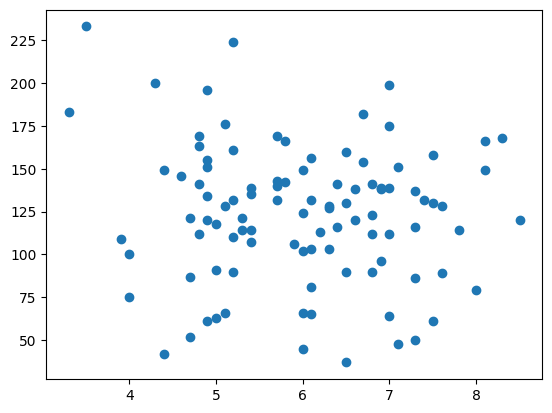

In [10]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'])

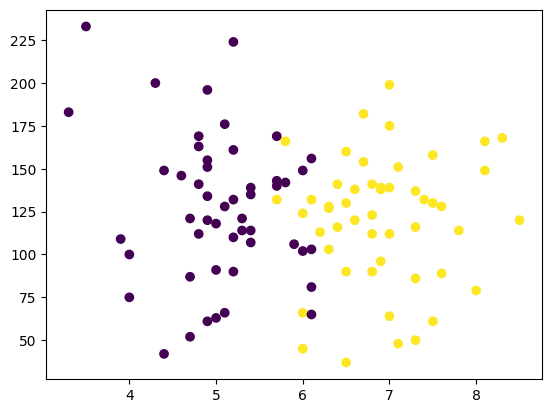

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
x=df.iloc[:,0:2]

In [13]:
y=df.iloc[:,-1]

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [17]:
x_train

,Unnamed: 0,cgpa
62,62,6.0
51,51,4.8
52,52,7.0
17,17,3.3
12,12,5.4
...,...,...
36,36,5.7
3,3,7.4
46,46,5.3
85,85,5.8


In [18]:
y_train

,placement
62,0
51,0
52,1
17,0
12,0
...,...
36,0
3,1
46,0
85,1


In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [21]:
x_train=scaler.fit_transform(x_train)

In [22]:
x_test=scaler.transform(x_test)

In [23]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [25]:
clf.fit(x_train,y_train)

LogisticRegression()

**model** **evaluation**

In [28]:
y_pred=clf.predict(x_test)

In [27]:
y_test

,placement
33,0
22,0
67,0
48,1
4,0
74,1
57,1
80,0
50,0
69,1


In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy_score(y_test,y_pred)

1.0

In [31]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

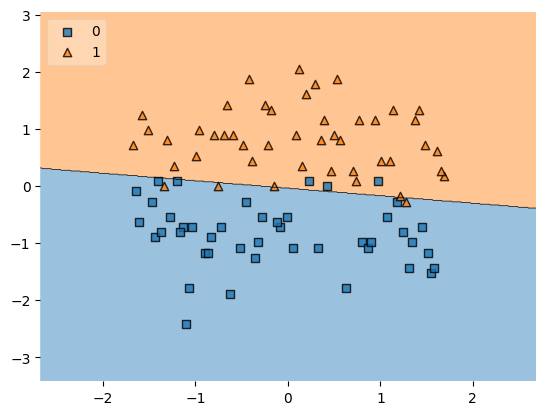

In [33]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [34]:
import pickle

In [36]:
pickle.dump(clf,open('model.pkl','wb'))